# OTT & Movie Ratings Trend Analysis

## Phase 3 — Advanced EDA & Business Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Phase 3 libraries loaded successfully!")

Phase 3 libraries loaded successfully!


In [2]:
# Load the processed dataset

file_path = "../data/processed/imdb_movies_ratings.csv"

df = pd.read_csv(file_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 156380
Columns: 14


In [3]:
# Prepare Data types for analysis

df["Release_Year"] = pd.to_numeric(
    df["Release_Year"],
    errors="coerce"
)

df["IMDb_Rating"] = pd.to_numeric(
    df["IMDb_Rating"],
    errors="coerce"
)

df["IMDb_Votes"] = pd.to_numeric(
    df["IMDb_Votes"],
    errors="coerce"
)

df["Runtime_Minutes"] = pd.to_numeric(
    df["Runtime_Minutes"],
    errors="coerce"
)

In [4]:
# Average Rating by Year

yearly_rating = (
    df.groupby("Release_Year")
      .agg(
          Average_Rating=("IMDb_Rating", "mean"),
          Median_Rating=("IMDb_Rating", "median"),
          Title_Count=("Title", "count"),
          Total_Votes=("IMDb_Votes", "sum")
      )
      .reset_index()
)

yearly_rating.head()

,Release_Year,Average_Rating,Median_Rating,Title_Count,Total_Votes
0,1980.0,6.214067,6.4,981,7171431
1,1981.0,6.245252,6.4,1032,5707199
2,1982.0,6.224647,6.3,1063,6672074
3,1983.0,6.240698,6.4,1118,6496917
4,1984.0,6.239378,6.4,1125,8955355


In [5]:
# Filter for Years with at Least 50 Movies

yearly_rating_filtered = yearly_rating[
    yearly_rating["Title_Count"] >= 50
].copy()

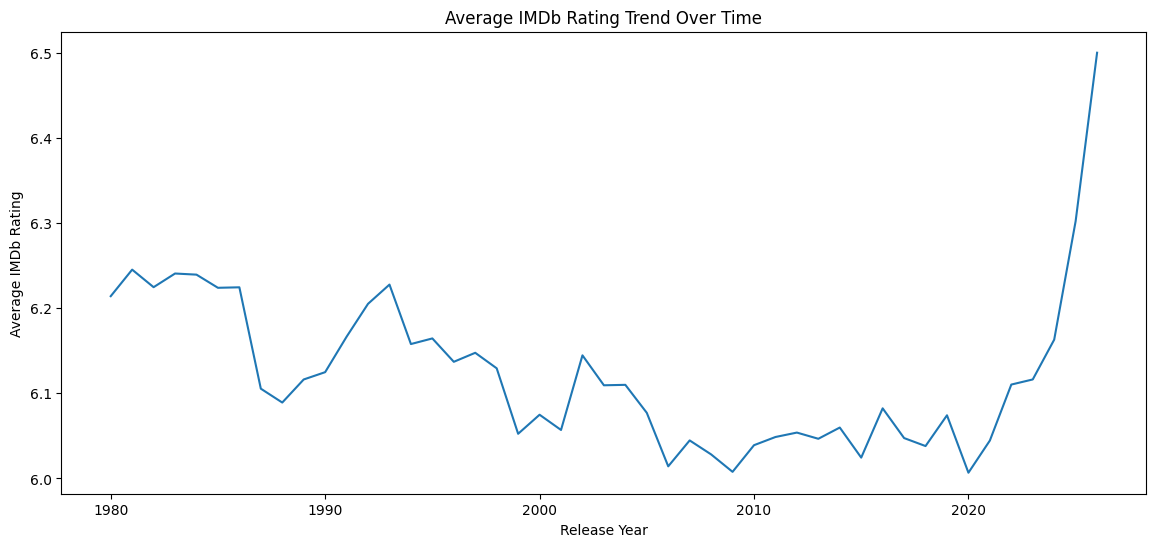

In [6]:
# Visualize the average IMDb rating trend over time using a line plot

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=yearly_rating_filtered,
    x="Release_Year",
    y="Average_Rating"
)

plt.title("Average IMDb Rating Trend Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average IMDb Rating")

plt.show()

In [7]:
# Best Rated Years

best_years = (
    yearly_rating_filtered
    .sort_values(
        "Average_Rating",
        ascending=False
    )
    .head(10)
)

best_years

,Release_Year,Average_Rating,Median_Rating,Title_Count,Total_Votes
46,2026.0,6.500045,6.6,2237,9068933
45,2025.0,6.302237,6.5,6170,26965834
1,1981.0,6.245252,6.4,1032,5707199
3,1983.0,6.240698,6.4,1118,6496917
4,1984.0,6.239378,6.4,1125,8955355
13,1993.0,6.227691,6.4,1412,15165426
2,1982.0,6.224647,6.3,1063,6672074
6,1986.0,6.224493,6.3,1233,8986215
5,1985.0,6.223928,6.4,1166,8608017
0,1980.0,6.214067,6.4,981,7171431


In [8]:
# Worst Rated Years

worst_years = (
    yearly_rating_filtered
    .sort_values(
        "Average_Rating",
        ascending=True
    )
    .head(10)
)

worst_years

,Release_Year,Average_Rating,Median_Rating,Title_Count,Total_Votes
40,2020.0,6.006710,6.2,5872,29806176
29,2009.0,6.007752,6.2,4025,44575677
26,2006.0,6.014213,6.2,3525,40578926
35,2015.0,6.024445,6.2,5629,47657060
28,2008.0,6.028237,6.2,3800,46261858
38,2018.0,6.038023,6.2,6746,45587029
30,2010.0,6.039043,6.3,4034,47738732
41,2021.0,6.044522,6.3,6608,41777455
27,2007.0,6.044647,6.2,3615,42523104
33,2013.0,6.046583,6.3,5122,57816729


In [9]:
# Average Rating by Genre

genre_df = df[
    [
        "Title",
        "Content_Type",
        "Release_Year",
        "Genres",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
].dropna(
    subset=["Genres"]
).copy()

genre_df["Genres"] = genre_df["Genres"].str.split(",")

genre_df = genre_df.explode("Genres")

genre_df["Genres"] = genre_df["Genres"].str.strip()

In [10]:
genre_df.head()

,Title,Content_Type,Release_Year,Genres,IMDb_Rating,IMDb_Votes
0,Kate & Leopold,movie,2001.0,Comedy,6.4,94417
0,Kate & Leopold,movie,2001.0,Fantasy,6.4,94417
0,Kate & Leopold,movie,2001.0,Romance,6.4,94417
1,"Another Time, Another Place",movie,1983.0,Drama,6.4,386
1,"Another Time, Another Place",movie,1983.0,War,6.4,386


In [11]:
# Calculate the average IMDb rating and number of votes for each genre

genre_performance = (
    genre_df.groupby("Genres")
    .agg(
        Titles=("Title", "count"),
        Average_Rating=("IMDb_Rating", "mean"),
        Median_Rating=("IMDb_Rating", "median"),
        Average_Votes=("IMDb_Votes", "mean")
    )
    .reset_index()
)

In [13]:
# Remove Tiny Genres

genre_reliable = genre_performance[
    genre_performance["Titles"] >= 100
].copy()

genre_reliable.sort_values(
    "Average_Rating",
    ascending=False
).head(15)

,Genres,Titles,Average_Rating,Median_Rating,Average_Votes
6,Documentary,17081,7.110017,7.2,1372.251976
20,Short,437,7.059497,7.2,1119.933638
11,History,5696,6.907935,7.1,7258.753160
3,Biography,5850,6.878581,7.0,14410.591282
13,Music,4034,6.684308,6.9,6545.351760
21,Sport,2822,6.640858,6.8,8012.097094
2,Animation,9372,6.627571,6.8,10794.493278
24,War,2242,6.508653,6.7,10096.126673
10,Game-Show,1140,6.326754,6.5,1249.340351
17,Reality-TV,3253,6.266400,6.5,968.928989


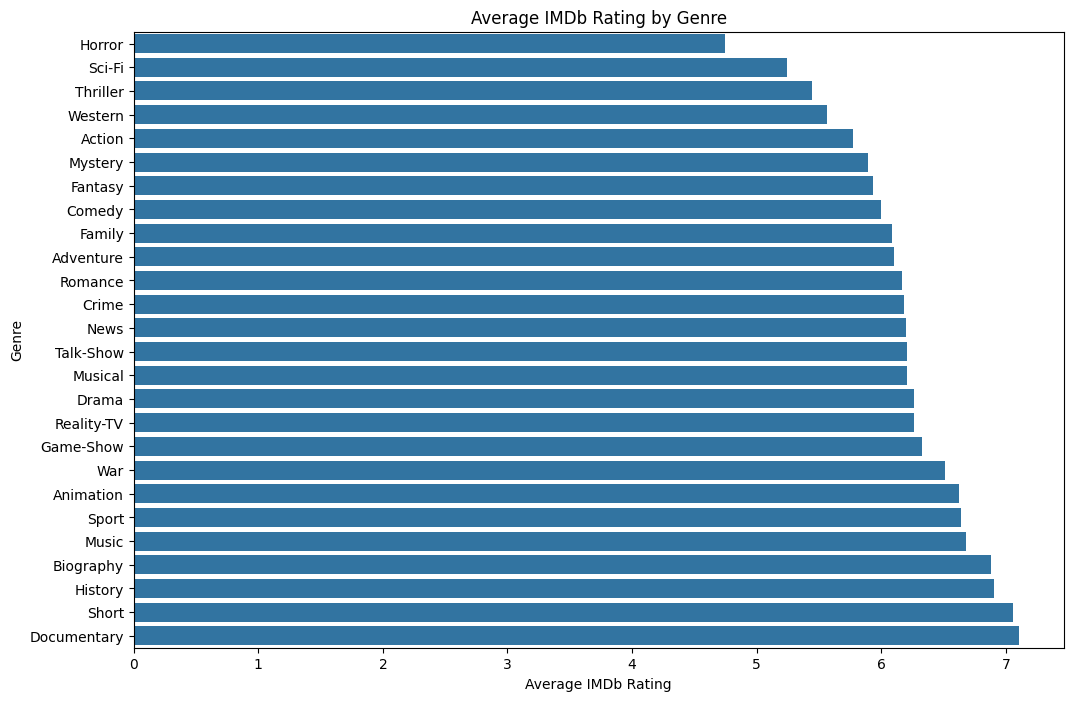

In [14]:
# Visualize the average IMDb rating by genre using a bar plot

plot_data = genre_reliable.sort_values(
    "Average_Rating",
    ascending=True
)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=plot_data,
    x="Average_Rating",
    y="Genres"
)

plt.title("Average IMDb Rating by Genre")
plt.xlabel("Average IMDb Rating")
plt.ylabel("Genre")

plt.show()

In [16]:
# Let's see which genres receive the most votes.

genre_popularity = (
    genre_df.groupby("Genres")
    .agg(
        Titles=("Title", "count"),
        Total_Votes=("IMDb_Votes", "sum"),
        Average_Votes=("IMDb_Votes", "mean")
    )
    .reset_index()
)

genre_popularity.sort_values(
    "Total_Votes",
    ascending=False
).head(15)

,Genres,Titles,Total_Votes,Average_Votes
7,Drama,74373,713694433,9596.149584
0,Action,21139,429385861,20312.496381
4,Comedy,48361,423031160,8747.361717
1,Adventure,12558,357844930,28495.375856
5,Crime,18063,284892454,15772.156010
23,Thriller,18224,228912188,12561.028753
19,Sci-Fi,5232,161307388,30830.922783
18,Romance,20190,158034997,7827.389648
15,Mystery,9393,154674868,16467.035878
12,Horror,14948,136794895,9151.384466


Reliable Top-Rated Titles

In [18]:
high_vote_titles = df[
    df["IMDb_Votes"] >= 10000
].copy()

top_reliable = (
    high_vote_titles
    .sort_values(
        ["IMDb_Rating", "IMDb_Votes"],
        ascending=[False, False]
    )
    .head(20)
)

top_reliable[
    [
        "Title",
        "Content_Type",
        "Release_Year",
        "Genres",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
]

,Title,Content_Type,Release_Year,Genres,IMDb_Rating,IMDb_Votes
46116,Breaking Bad,tvSeries,2008.0,"Crime,Drama,Thriller",9.5,2656080
123405,Steel Ball Run: JoJo's Bizarre Adventure,tvSeries,2026.0,"Action,Adventure,Animation",9.5,26062
21349,Band of Brothers,tvMiniSeries,2001.0,"Action,Drama,History",9.4,600758
43600,Planet Earth,tvMiniSeries,2006.0,"Documentary,Family",9.4,236200
135141,Planet Earth II,tvMiniSeries,2016.0,"Documentary,Family",9.4,176240
12980,The Shawshank Redemption,movie,1994.0,Drama,9.3,3221305
145668,Chernobyl,tvMiniSeries,2019.0,"Drama,History,Thriller",9.3,1055478
37048,Avatar: The Last Airbender,tvSeries,2005.0,"Action,Adventure,Animation",9.3,451748
29997,The Wire,tvSeries,2002.0,"Crime,Drama,Thriller",9.3,436151
142693,Blue Planet II,tvMiniSeries,2017.0,"Documentary,Family",9.3,58344


Rating vs Popularity

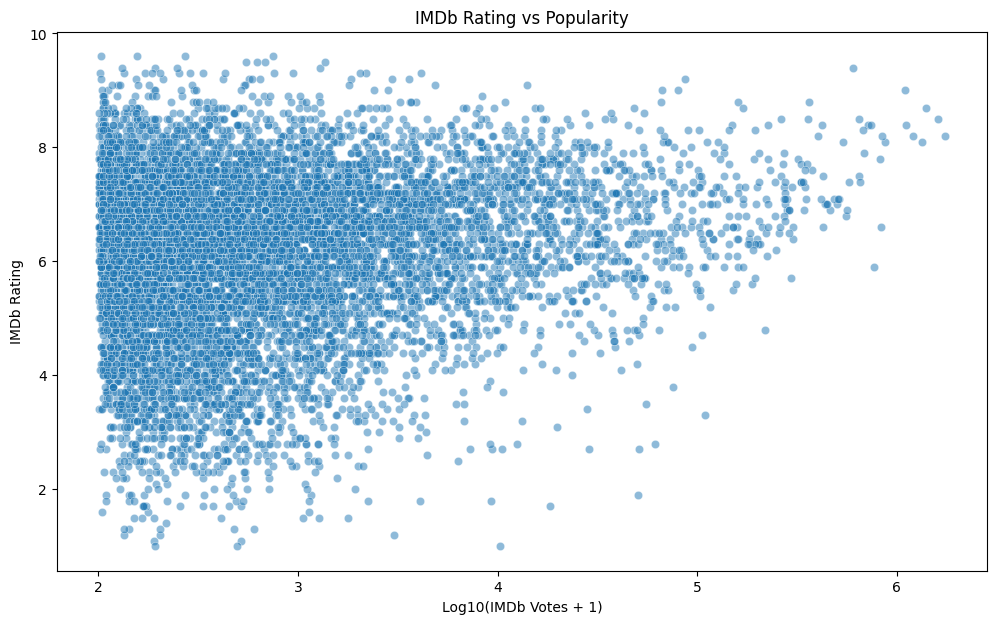

In [19]:
df["Log_Votes"] = np.log10(
    df["IMDb_Votes"] + 1
)

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df.sample(
        min(10000, len(df)),
        random_state=42
    ),
    x="Log_Votes",
    y="IMDb_Rating",
    alpha=0.5
)

plt.title("IMDb Rating vs Popularity")
plt.xlabel("Log10(IMDb Votes + 1)")
plt.ylabel("IMDb Rating")

plt.show()



Correlation With Log Votes

In [20]:
correlation = df[
    ["IMDb_Rating", "Log_Votes"]
].corr()

correlation

corr_value = correlation.loc[
    "IMDb_Rating",
    "Log_Votes"
]

print(
    f"Rating vs Log Votes Correlation: {corr_value:.3f}"
)



Rating vs Log Votes Correlation: 0.165


Movie vs TV: Deeper Comparison

In [21]:
content_analysis = (
    df.groupby("Content_Type")
    .agg(
        Titles=("Title", "count"),
        Average_Rating=("IMDb_Rating", "mean"),
        Median_Rating=("IMDb_Rating", "median"),
        Average_Votes=("IMDb_Votes", "mean"),
        Total_Votes=("IMDb_Votes", "sum")
    )
    .reset_index()
)

content_analysis

,Content_Type,Titles,Average_Rating,Median_Rating,Average_Votes,Total_Votes
0,movie,115741,5.827577,6.0,10150.425847,1174820438
1,tvMiniSeries,7923,7.153061,7.2,3705.898145,29361831
2,tvSeries,32716,6.800550,7.0,5351.870705,175091802


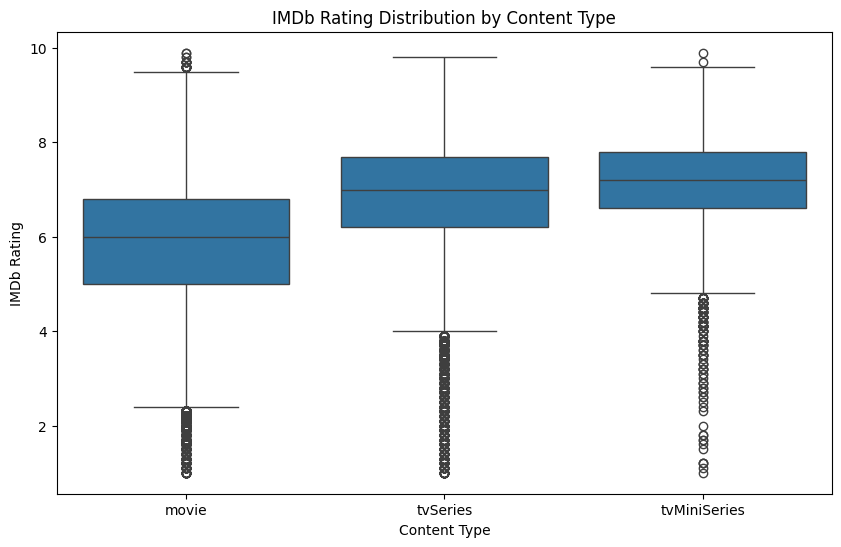

In [22]:
# Visualize the IMDb rating distribution by content type using a box plot

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Content_Type",
    y="IMDb_Rating"
)

plt.title("IMDb Rating Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("IMDb Rating")

plt.show()

Decade × Content Type

In [23]:
decade_type = (
    df.groupby(
        ["Decade", "Content_Type"]
    )
    .agg(
        Titles=("Title", "count"),
        Average_Rating=("IMDb_Rating", "mean")
    )
    .reset_index()
)

decade_type.head()

,Decade,Content_Type,Titles,Average_Rating
0,1980.0,movie,9977,5.977759
1,1980.0,tvMiniSeries,435,7.488506
2,1980.0,tvSeries,1508,7.186340
3,1990.0,movie,12227,5.916603
4,1990.0,tvMiniSeries,549,7.142805


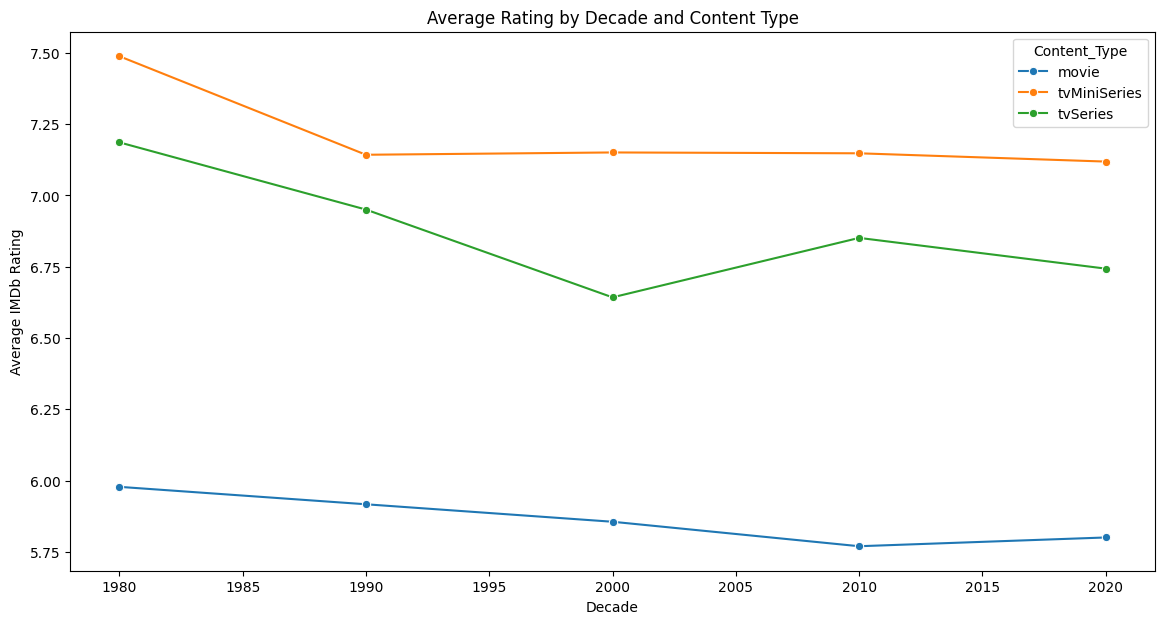

In [24]:
# Visualize the average IMDb rating by decade and content type using a line plot 

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=decade_type,
    x="Decade",
    y="Average_Rating",
    hue="Content_Type",
    marker="o"
)

plt.title("Average Rating by Decade and Content Type")
plt.xlabel("Decade")
plt.ylabel("Average IMDb Rating")

plt.show()

Rating Category by Content Type

In [25]:
rating_type = pd.crosstab(
    df["Content_Type"],
    df["Rating_Category"],
    normalize="index"
) * 100

rating_type.round(2)

Rating_Category,Average,Excellent,Good,Low Rated,Masterpiece
Content_Type,,,,,
movie,31.31,2.94,17.03,48.46,0.27
tvMiniSeries,27.78,17.90,44.01,9.13,1.19
tvSeries,27.98,15.24,35.55,19.94,1.29


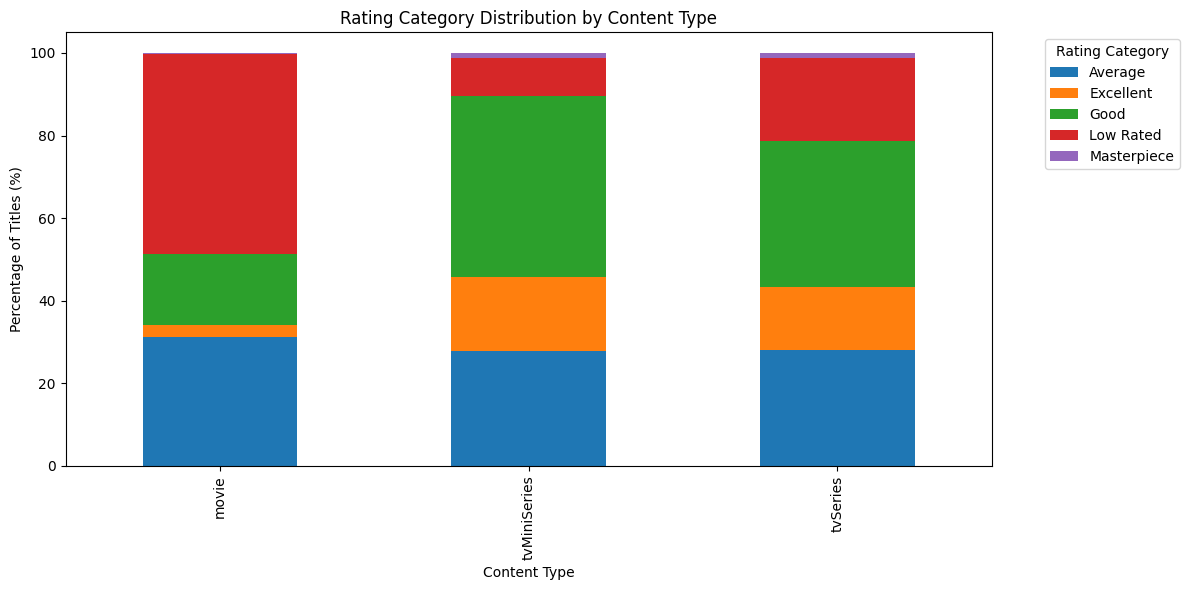

In [26]:
# Visualize the rating category distribution by content type using a stacked bar plot

rating_type.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Rating Category Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Percentage of Titles (%)")

plt.legend(
    title="Rating Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

Runtime Analysis

In [27]:
runtime_df = df[
    df["Runtime_Minutes"].notna()
].copy()

runtime_df = runtime_df[
    (runtime_df["Runtime_Minutes"] >= 20) &
    (runtime_df["Runtime_Minutes"] <= 300)
]

In [28]:
runtime_summary = (
    runtime_df.groupby("Content_Type")
    .agg(
        Average_Runtime=("Runtime_Minutes", "mean"),
        Median_Runtime=("Runtime_Minutes", "median")
    )
    .reset_index()
)

runtime_summary

,Content_Type,Average_Runtime,Median_Runtime
0,movie,100.983728,97.0
1,tvMiniSeries,74.983811,55.0
2,tvSeries,46.933321,43.0


Runtime vs Rating

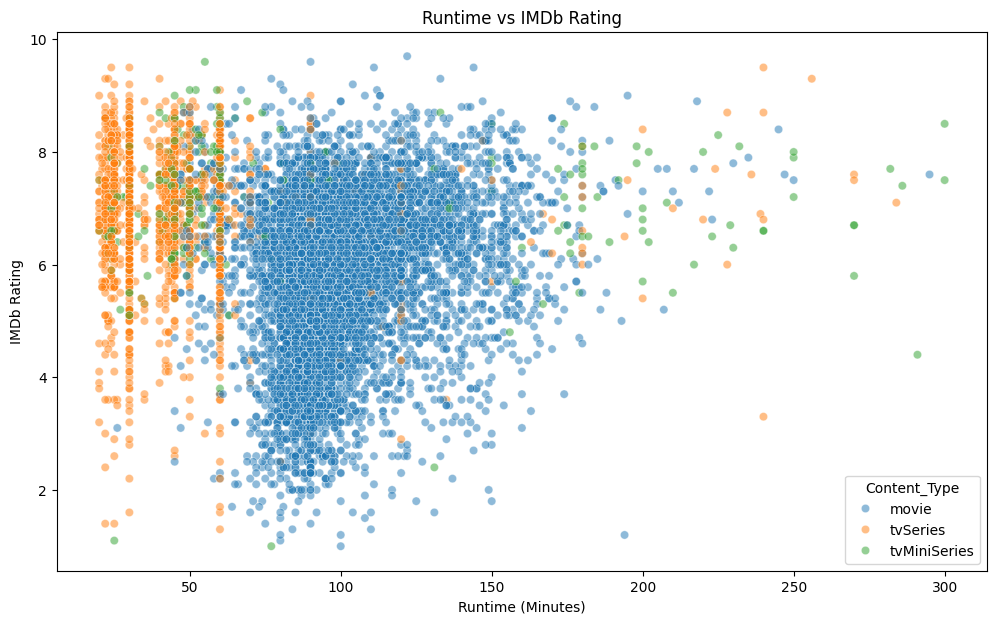

In [30]:
# Visualize the relationship between runtime and IMDb rating using a scatter plot

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=runtime_df.sample(
        min(10000, len(runtime_df)),
        random_state=42
    ),
    x="Runtime_Minutes",
    y="IMDb_Rating",
    hue="Content_Type",
    alpha=0.5
)

plt.title("Runtime vs IMDb Rating")
plt.xlabel("Runtime (Minutes)")
plt.ylabel("IMDb Rating")

plt.show()

Outlier Detection

In [31]:
Q1 = df["IMDb_Votes"].quantile(0.25)
Q3 = df["IMDb_Votes"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + (1.5 * IQR)

print("Upper Vote Outlier Limit:", upper_limit)

Upper Vote Outlier Limit: 4050.0


In [32]:
vote_outliers = df[
    df["IMDb_Votes"] > upper_limit
].copy()

print(
    "Number of vote outliers:",
    len(vote_outliers)
)

Number of vote outliers: 23831


In [33]:
vote_outliers.sort_values(
    "IMDb_Votes",
    ascending=False
)[
    [
        "Title",
        "IMDb_Rating",
        "IMDb_Votes"
    ]
].head(20)

,Title,IMDb_Rating,IMDb_Votes
12980,The Shawshank Redemption,9.3,3221305
40730,The Dark Knight,9.1,3207389
66548,Inception,8.8,2851551
46116,Breaking Bad,9.5,2656080
46713,Game of Thrones,9.2,2646209
18014,Fight Club,8.8,2644328
44302,Interstellar,8.7,2583532
12503,Forrest Gump,8.8,2521446
12892,Pulp Fiction,8.8,2456470
17774,The Matrix,8.7,2267463


Create an Analytical Score

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["Popularity_Score"] = scaler.fit_transform(
    df[["Log_Votes"]]
)

Create Custom OTT Success Score

In [35]:
df["Rating_Score"] = (
    df["IMDb_Rating"] / 10
)

df["Content_Success_Score"] = (
    0.70 * df["Rating_Score"]
    +
    0.30 * df["Popularity_Score"]
) * 100

df[
    [
        "Title",
        "IMDb_Rating",
        "IMDb_Votes",
        "Content_Success_Score"
    ]
].sort_values(
    "Content_Success_Score",
    ascending=False
).head(20)

,Title,IMDb_Rating,IMDb_Votes,Content_Success_Score
46116,Breaking Bad,9.5,2656080,95.941856
12980,The Shawshank Redemption,9.3,3221305,95.100000
46713,Game of Thrones,9.2,2646209,93.831085
40730,The Dark Knight,9.1,3207389,93.687476
20047,The Lord of the Rings: The Return of the King,9.0,2182912,91.874291
145668,Chernobyl,9.3,1055478,91.872112
66548,Inception,8.8,2851551,91.247286
16732,The Lord of the Rings: The Fellowship of the Ring,8.9,2226102,91.230970
18014,Fight Club,8.8,2644328,91.029028
11809,Schindler's List,9.0,1596573,90.969388


Top Content by Custom Score

In [36]:
top_success = (
    df.sort_values(
        "Content_Success_Score",
        ascending=False
    )
    .head(20)
)

In [37]:
top_success[
    [
        "Title",
        "Content_Type",
        "Release_Year",
        "IMDb_Rating",
        "IMDb_Votes",
        "Content_Success_Score"
    ]
]

,Title,Content_Type,Release_Year,IMDb_Rating,IMDb_Votes,Content_Success_Score
46116,Breaking Bad,tvSeries,2008.0,9.5,2656080,95.941856
12980,The Shawshank Redemption,movie,1994.0,9.3,3221305,95.100000
46713,Game of Thrones,tvSeries,2011.0,9.2,2646209,93.831085
40730,The Dark Knight,movie,2008.0,9.1,3207389,93.687476
20047,The Lord of the Rings: The Return of the King,movie,2003.0,9.0,2182912,91.874291
145668,Chernobyl,tvMiniSeries,2019.0,9.3,1055478,91.872112
66548,Inception,movie,2010.0,8.8,2851551,91.247286
16732,The Lord of the Rings: The Fellowship of the Ring,movie,2001.0,8.9,2226102,91.230970
18014,Fight Club,movie,1999.0,8.8,2644328,91.029028
11809,Schindler's List,movie,1993.0,9.0,1596573,90.969388


Create Final Business Metrics

In [38]:
# Visualize the top 20 content success scores using a bar plot

business_metrics = {
    "Total Titles": len(df),

    "Average Rating": round(
        df["IMDb_Rating"].mean(), 2
    ),

    "Median Rating": round(
        df["IMDb_Rating"].median(), 2
    ),

    "Total IMDb Votes": int(
        df["IMDb_Votes"].sum()
    ),

    "Highest Rating": df["IMDb_Rating"].max(),

    "Most Popular Title": df.loc[
        df["IMDb_Votes"].idxmax(),
        "Title"
    ],

    "Highest Rated Title": df.loc[
        df["IMDb_Rating"].idxmax(),
        "Title"
    ]
}

business_metrics

{'Total Titles': 156380,
 'Average Rating': np.float64(6.1),
 'Median Rating': np.float64(6.3),
 'Total IMDb Votes': 1379274071,
 'Highest Rating': np.float64(9.9),
 'Most Popular Title': 'The Shawshank Redemption',
 'Highest Rated Title': 'Lyonheart Universe'}

In [39]:
# Save the advanced dataset to a CSV file

advanced_output = (
    "../data/processed/"
    "imdb_movies_ratings_advanced.csv"
)

df.to_csv(
    advanced_output,
    index=False
)

print("Advanced dataset saved!")
print(advanced_output)

Advanced dataset saved!
../data/processed/imdb_movies_ratings_advanced.csv


In [40]:
# Save the analysis tables to CSV files

yearly_rating_filtered.to_csv(
    "../data/processed/yearly_rating_trend.csv",
    index=False
)

genre_reliable.to_csv(
    "../data/processed/genre_performance.csv",
    index=False
)

content_analysis.to_csv(
    "../data/processed/content_type_analysis.csv",
    index=False
)

runtime_summary.to_csv(
    "../data/processed/runtime_analysis.csv",
    index=False
)

print("Analysis tables saved successfully!")

Analysis tables saved successfully!
